Nome: Tiago Silveira Zaparoli

RA: 237310

Curso: Engenharia de Computação (34), modalidade AB



# Ex01 - Aprendendo Numpy

Na aula de hoje, vamos nos familiarizar com operações envolvendo arrays em Python, vetorização de operações e manipulação básica de imagens.

As questões nesta aula são dividias em 2 tipos:


- 🤖🚫: Por favor, não utilize o auxílio de uma IA nesta questão, ela pode prejudicar seu aprendizado e impedir o objetivo esperado para esta questão
- 🤖🆗: Utilize o auxílio de uma IA se julgar necessário. Tente entender as respostas geradas por ela, e chame ajuda para isto, se precisar

In [52]:
# Importando as bibliotecas que serão utilizadas
from io import BytesIO

import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
from PIL import Image, ImageFile
import requests

## Parte 1 - Exercitando o uso do Numpy 🤖🚫

### Visualizando arrays em forma de imagem

In [53]:
f = np.ones((100,120))
print("Imagem constante:\n",f)
print("Dimensões da imagem:",f.shape)

Imagem constante:
 [[1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 ...
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]]
Dimensões da imagem: (100, 120)


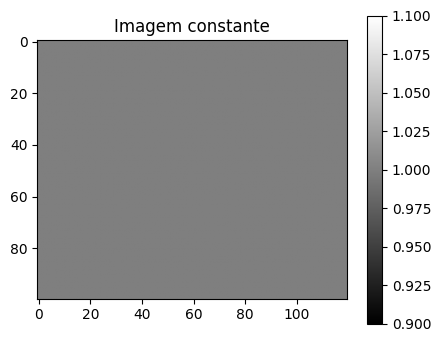

In [54]:
plt.figure(figsize=(5, 4))
plt.imshow(f,cmap='gray')
plt.title('Imagem constante')
plt.colorbar()

## Parte 2 - Manipulando arrays com Numpy 🤖🚫



Nesta seção, serão abordados os métodos empregados nos tutoriais disponíveis em ["Aprendendo Numpy"](https://github.com/lrittner/Computacao-Visual/blob/master/tutoriais/02_Aprendendo_Numpy.ipynb).

**Note que os arrays (as imagens) NUNCA devem ser "varridos" elemento a elemento (pixel a pixel)! Ou seja, ao invés de acessar individualmente cada posição de um array usando *for*, deve-se utilizar o fatiamento (slicing) e as funções de manipulação de array fornecidas pelo Numpy.**

### Exercício 2.1

**a)** Crie um array do numpy, **a**, formado apenas por elementos "1", de tipo "int16", com 5 linhas e 3 colunas. Printe o array criado;

<details>
  <summary>Dicas</summary>

  - [numpy.ones](https://numpy.org/doc/stable/reference/generated/numpy.ones.html)
  - [Tipos](https://numpy.org/doc/stable/reference/arrays.scalars.html#sized-aliases)
  
</details>

In [55]:
# O array a foi criado utilizando o método np.ones(), que preenche um array de
# formato configurável via tupla com números 1 em conformidade com o tipo de
# dado escolhido, no caso np.int16.

a = np.ones((5, 3), dtype=np.int16)
print("Array criado:\n",a)
print("Dimensões do array:",a.shape)

Array criado:
 [[1 1 1]
 [1 1 1]
 [1 1 1]
 [1 1 1]
 [1 1 1]]
Dimensões do array: (5, 3)


**b)** Crie um novo array **b** a partir do array **a**. Altere o elemento da 3ª linha e 2ª coluna do array **b** para zero (0), sem que o array **a** seja alterado. Comente a metodologia empregada e printe os arrays **a** e **b**;

<details>
  <summary>Dicas</summary>

  - [numpy.ndarray.copy](https://numpy.org/doc/stable/reference/generated/numpy.ndarray.copy.html) e [numpy.copy](https://numpy.org/doc/stable/reference/generated/numpy.copy.html)
  
</details>

In [56]:
# O método ndarray.copy permite realizar uma cópia de um array numpy sem que o
# novo array aponte para o original, permitindo que alterações sejam feitas no
# novo array sem que o original seja modificado.
#
# Desta forma, b é criado a partir de tal método aplicado ao array a.
# Em seguida o elemento de b é alterado, de forma que o array a permanece intacto.

b = np.ndarray.copy(a)
b[2, 1] = 0

print("Array a:\n",a)
print("\nArray b:\n",b)

Array a:
 [[1 1 1]
 [1 1 1]
 [1 1 1]
 [1 1 1]
 [1 1 1]]

Array b:
 [[1 1 1]
 [1 1 1]
 [1 0 1]
 [1 1 1]
 [1 1 1]]


**c)** Muitas vezes, estamos interessados em manipular pixels ou regiões específicas de uma imagem. Podemos utilizar o fatiamento (slicing) para criar um array auxiliar dos pixels que queremos manipular. Assim, ao modificar o array auxiliar, apenas os pixels de interesse serão alterados no array original. Para exercitar esse processo, altere o valor de todos os elementos da 2ª coluna do array **b** para 2, utilizando o fatiamento (slicing) e um array auxiliar **c**.  Comente a metodologia empregada e printe os arrays **b** e **c**;

<details>
  <summary>Dicas</summary>

  - [NumPy: the absolute basics for beginners - Indexing and Slicing](https://numpy.org/doc/stable/user/absolute_beginners.html#indexing-and-slicing)
  
</details>

In [57]:
# O processo de atribuicao do valor de c faz com que o array c contenha apenas
# os elementos na segunda coluna de b. Porém, a forma como tal processo é feito
# faz com que os elementos de c referenciem os mesmos elementos de b.
c = b[:, 1]
print("Array c antes da modificacao:\n",c)
print("Array b antes da modificacao:\n",b)

# Desta forma, ao alterar o valor dos elementos de c, alteram-se os elementos
# referenciados de b.
c[:] = 2

print("\nArray c apos a modificacao:\n",c)
print("Array b apos a modificacao:\n",b)

Array c antes da modificacao:
 [1 1 0 1 1]
Array b antes da modificacao:
 [[1 1 1]
 [1 1 1]
 [1 0 1]
 [1 1 1]
 [1 1 1]]

Array c apos a modificacao:
 [2 2 2 2 2]
Array b apos a modificacao:
 [[1 2 1]
 [1 2 1]
 [1 2 1]
 [1 2 1]
 [1 2 1]]


### Exercício 2.2



**a)** Crie um array do numpy, **d**, formado por 21 elementos sequenciais, com valor inicial 0, valor final 100 e passo 5. Printe o array criado e comente a metodologia utilizada;

<details>
  <summary>Dicas</summary>

  - [numpy.arange](https://numpy.org/doc/stable/reference/generated/numpy.arange.html)
  - [numpy.linspace](https://numpy.org/doc/stable/reference/generated/numpy.linspace.html)
  
</details>

In [58]:
# O método np.arange() permite a criação de um array com um range de valores
# configurável, o que ocorre via especificação do ponto de início, fim e do
# passo entre cada elemento. O intervalo criado é, por padrão, fechado à
# esquerda e aberto à direita, [íncio, fim).

d = np.arange(0, 101, 5)
print("Array d:\n",d)

Array d:
 [  0   5  10  15  20  25  30  35  40  45  50  55  60  65  70  75  80  85
  90  95 100]


**b)** Altere o array **d** para que este possua 7 linhas e 3 colunas. Printe o array resultante e comente a metodologia utilizada;

<details>
  <summary>Dicas</summary>

  - [NumPy: the absolute basics for beginners - Can you reshape an array?](https://numpy.org/doc/stable/user/absolute_beginners.html#can-you-reshape-an-array)
  - [numpy.ndarray.reshape](https://numpy.org/doc/stable/reference/generated/numpy.ndarray.reshape.html) e [numpy.reshape](https://numpy.org/doc/stable/reference/generated/numpy.reshape.html)
  
</details>

In [59]:
# O método np.reshape() permite alterar o formato do array através de uma tupla
# (linhas, colunas), conservando os valores e reorganizando suas posições.

print("Array d original:\n", d)
d = np.reshape(d, (7, 3))
print("\nArray d após o reshape:\n", d)
print("\nDimensoes de d:", d.shape)

Array d original:
 [  0   5  10  15  20  25  30  35  40  45  50  55  60  65  70  75  80  85
  90  95 100]

Array d após o reshape:
 [[  0   5  10]
 [ 15  20  25]
 [ 30  35  40]
 [ 45  50  55]
 [ 60  65  70]
 [ 75  80  85]
 [ 90  95 100]]

Dimensoes de d: (7, 3)


**c)** Utilizando fatiamento (slicing), efetue a inversão dos elementos do array **d** (primeiro elemento [0,0] vira o último [6,2], segundo elemento [0,1] vira o penúltimo [6,1], ...) sem alterar o shape original do array. Printe o array resultante e comente a metodologia utilizada;

<details>
  <summary>Dicas</summary>

  - [Indexing on ndarrays - Slicing and striding](https://numpy.org/doc/stable/user/basics.indexing.html#slicing-and-striding) (dica 2: "negative k")
    
</details>

In [60]:
# O slicing de um array numpy tem a forma i:j:k, em que i e j correspondem aos
# valores de início e fim, respectivamente, e k representa a ordem/passo de
# contagem. Desta forma, ao utilizar ::k, está o slicing especifica todos os
# elementos da linha/coluna do array e os percorre com ordem/passo k. Já ao
# utilizar ::-1, especifica-se todos os elementos da linha/coluna do array em
# ordem invertida.
#
# Logo, array[::-1, ::] inverte as linhas de ordem, array[::, ::-1] inverte as
# colunas de ordem, e array[::-1, ::-1] faz ambos ao mesmo tempo.

print("Array d antes da inversao:\n", d)
d = d[::-1, ::-1]
print("\nArray d apos a inversao:\n", d)

Array d antes da inversao:
 [[  0   5  10]
 [ 15  20  25]
 [ 30  35  40]
 [ 45  50  55]
 [ 60  65  70]
 [ 75  80  85]
 [ 90  95 100]]

Array d apos a inversao:
 [[100  95  90]
 [ 85  80  75]
 [ 70  65  60]
 [ 55  50  45]
 [ 40  35  30]
 [ 25  20  15]
 [ 10   5   0]]


**d)** Utilizando fatiamento no array resultante no item anterior, printe apenas os elementos da 4ª à 5ª linhas e da 2ª à 3ª colunas.  Comente a metodologia utilizada.

In [61]:
# Aqui o slicing é utlizado para especificar as linhas e colunas desejadas,
# lembrando-se que o slicing é não inclusivo à direita, isto é, um slicing i:j
# captura todos os elementos i <= x < j.
#
# Assim, para 4a (índice 3) e 5a (índice 4) linhas: 3:5.
# E para 2a (índice 1) e 3a (índice 2) colunas: 1:3.

print("4a e 5a linhas, 2a e 3a colunas do array d:\n", d[3:5, 1:3])

4a e 5a linhas, 2a e 3a colunas do array d:
 [[50 45]
 [35 30]]


**e)** Altere o array **d** para que ele volte a possuir apenas uma dimensão. Printe o array resultante e comente a metodologia utilizada.

<details>
  <summary>Dicas</summary>

  - `reshape` pode ser útil aqui, mas existem opções mais práticas
  - [numpy.ndarray.flatten](https://numpy.org/doc/stable/reference/generated/numpy.ndarray.flatten.html)
  - [numpy.ndarray.ravel](https://numpy.org/doc/stable/reference/generated/numpy.ravel.html)
  - _quais das opções acima é mais eficiente em uso de memória?_
  
</details>

In [62]:
# O método np.ndarray.flatten() colapsa um array numpy em apenas um array de 1
# linha.

d = np.ndarray.flatten(d)
print("Array d:\n", d)

Array d:
 [100  95  90  85  80  75  70  65  60  55  50  45  40  35  30  25  20  15
  10   5   0]


### Exercício 2.3

**a)** Crie um array do numpy, **e**, formado por 35 elementos sequenciais, com:

- valor inicial 0;
- valor final 34;
- passo 1;
- shape (5,7) (primeira linha com valores 0-6, segunda linha com valores 7-13, etc).

Printe o array criado, seu shape e comente a metodologia utilizada;

<details>
  <summary>Dicas</summary>

  - Isso é uma combinação de funções que você já utilizou anteriormente, encadeadas uma após a outra.
  
</details>

In [63]:
# Utilizando-se np.arrange() é possível especificar os valores pretendidos, ao
# tomar início = 0, fim = 35 e passo = 1. O formato do vetor é garantido pelo
# método np.reshape(), com tupla (5,7) como parâmetro de formato.

e = np.arange(0, 35, 1)
e = np.reshape(e, (5,7))
print("Array e:\n", e)

Array e:
 [[ 0  1  2  3  4  5  6]
 [ 7  8  9 10 11 12 13]
 [14 15 16 17 18 19 20]
 [21 22 23 24 25 26 27]
 [28 29 30 31 32 33 34]]


**b)** Utilize um array booleano e indexação para printar apenas os elementos do array **e** que são maiores que 20. Comente a metodologia utilizada.

_Info: um "array booleano" também é chamado de "máscara"_

<details>
  <summary>Dicas</summary>

  - [Indexing on ndarrays - Boolean array indexing](https://numpy.org/doc/stable/user/basics.indexing.html#boolean-array-indexing)
  
</details>

In [64]:
# Ao realizar a atribuição mask = e > 20, o array mask é construído utilizando
# valores booleanos que correspondem ao resultado da comparação com o respectivo
# elemento. Ao aplicar e[mask], apenas os elementos que satisfazem a comparação
# são selecionados de e.

mask = e > 20
print("Array e original:\n", e)
print("\nFormato da máscara:\n", mask)
print("\nArray apenas com elementos maiores que 20:\n", e[mask])

Array e original:
 [[ 0  1  2  3  4  5  6]
 [ 7  8  9 10 11 12 13]
 [14 15 16 17 18 19 20]
 [21 22 23 24 25 26 27]
 [28 29 30 31 32 33 34]]

Formato da máscara:
 [[False False False False False False False]
 [False False False False False False False]
 [False False False False False False False]
 [ True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True]]

Array apenas com elementos maiores que 20:
 [21 22 23 24 25 26 27 28 29 30 31 32 33 34]


**c)** Utilize um array booleano e indexação para printar apenas as colunas do array **e** cuja soma dos elementos resulte em um valor par. Comente a metodologia utilizada.

<details>
  <summary>Dicas</summary>
  
  - [numpy.sum](https://numpy.org/doc/stable/reference/generated/numpy.sum.html), observe o parâmetro `axis` (você sempre pode chutar o valor para entender o que está acontecendo)
  - Crie uma máscara com a condição descrita
  - O array final terá um shape (5, ???)

</details>

In [65]:
# O método np.sum() realiza a soma dos elementos de um array no eixo
# especificado (0 representa uma soma de colunas, 1 uma soma de linhas).
# Utilizando uma máscara no resultado da soma é possível capturar apenas as
# colunas do array da soma que satisfazem à condição. Desta forma, aplicar a
# máscara ao array na posição das colunas permite extrair apenas as colunas
# satisfazendo à condição.

linesum = np.sum(e, axis=0)
print("Soma das colunas:\n", linesum)
mask = linesum % 2 == 0
print("\nMáscara:\n", mask)
print("\nArray final:\n", e[:, mask])

Soma das colunas:
 [ 70  75  80  85  90  95 100]

Máscara:
 [ True False  True False  True False  True]

Array final:
 [[ 0  2  4  6]
 [ 7  9 11 13]
 [14 16 18 20]
 [21 23 25 27]
 [28 30 32 34]]


### Exercício 2.4



Crie uma função que tenha como entradas:
- Inteiro **m** que corresponde às linhas de uma matriz;
- Inteiro **n** que corresponde às colunas de uma matriz;

e que retorne:
- Uma matriz **X** de shape (m, n), em que cada elemento X[i,j] seja a distância Euclidiana entre a posição [i,j] e a posição [0,0] (ou seja, X[i,j] = módulo de (i,j)).

Teste a função com os valores **m=5** e **n=4**.

<details>
  <summary>Dicas</summary>

  Você pode pensar nessa questão em duas partes: gerar os índices + calcular o módulo deles. Cada parte pode ser feita de várias formas:

  Gerar os índices
  - [numpy.indices](https://numpy.org/doc/stable/reference/generated/numpy.indices.html)
  - [numpy.meshgrid](https://numpy.org/doc/stable/reference/generated/numpy.meshgrid.html) e [numpy.arange](https://numpy.org/doc/stable/reference/generated/numpy.arange.html)
  - [numpy.argwhere](https://numpy.org/doc/stable/reference/generated/numpy.argwhere.html) e [numpy.ones](https://numpy.org/doc/stable/reference/generated/numpy.ones.html)

  A função [numpy.ndarray.transpose](https://numpy.org/doc/stable/reference/generated/numpy.ndarray.transpose.html) pode ser útil.

  Calcular o módulo
  - [numpy.linalg.norm](https://numpy.org/doc/stable/reference/generated/numpy.linalg.norm.html)
  - [numpy.power](https://numpy.org/doc/stable/reference/generated/numpy.power.html) e [numpy.sqrt](https://numpy.org/doc/stable/reference/generated/numpy.sqrt.html)
  
  
</details>

In [66]:
# O método np.indices() cria um array de shape configurável (m, n), com dimensão
# (2, m, n). Desta forma a distância euclidiana pode ser calculada ao fazer
# raiz quadrada do quadrado da primeira componente do array gerado acrescoda do
# quadrado da segunda componente: sqrt(a[0]² + a[1]²), o que representa a
# distância entre a origem e um ponto de coordenadas (a[0], a[1]).

def euclidian(m, n):
  idx = np.indices((m, n))
  X = np.sqrt(np.power(idx[0], 2) + np.power(idx[1], 2))
  return X
print("Array de índices:\n", np.indices((5, 4)))
print("\nArray de distâncias:\n", euclidian(5, 4))


Array de índices:
 [[[0 0 0 0]
  [1 1 1 1]
  [2 2 2 2]
  [3 3 3 3]
  [4 4 4 4]]

 [[0 1 2 3]
  [0 1 2 3]
  [0 1 2 3]
  [0 1 2 3]
  [0 1 2 3]]]

Array de distâncias:
 [[0.         1.         2.         3.        ]
 [1.         1.41421356 2.23606798 3.16227766]
 [2.         2.23606798 2.82842712 3.60555128]
 [3.         3.16227766 3.60555128 4.24264069]
 [4.         4.12310563 4.47213595 5.        ]]


## Parte 3 - Imagens sinteticas 🤖🚫

Veja um exemplo de criação de uma imagem sintética com Numpy e como visualizá-la com o matplotlib.pyplot:


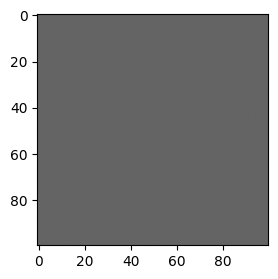

In [67]:
# Criação de um quadrado cinza com dimensões 100 x 100
array = np.zeros([100, 100], dtype=np.uint8)
array[:,:] = [100]
plt.figure(figsize = (3,3))
plt.imshow(array,vmin=0, vmax=255, cmap='gray')

### Exercício 3.1

**a)** Crie um retângulo de tamanho 100 x 200 que seja formado por dois quadrados, um cinza claro e um cinza escuro. Plote o resultado obtido e comente a metodologia utilizada.

<details>
  <summary>Dicas</summary>

  Primeiro crie o array, depois defina os valores usando slicing e broadcasting.
  
</details>

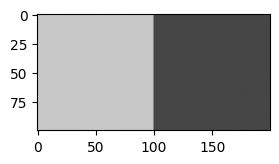

In [68]:
# Primeiramente quadrados 100x100 foram criados e suas cores foram configuradas.
# Após isso, o retângulo 100x200 foi criado e composto via slicing e
# broadcasting.

square1 = np.zeros([100, 100], dtype=np.uint8)
square2 = np.zeros([100, 100], dtype=np.uint8)

square1[:, :] = 200
square2[:, :] = 70

rect = np.zeros([100, 200], dtype=np.uint8)
rect[:, :100] = square1
rect[:, 100:200] = square2

plt.figure(figsize = (3,3))
plt.imshow(rect,vmin=0, vmax=255, cmap='gray')

**b)** Utilizando a imagem anterior (retângulo criado), efetue a inserção de um quadrado cinza claro no meio do quadrado cinza escuro e de um quadrado cinza escuro no meio do quadrado cinza claro. Plote o resultado obtido e comente a metodologia utilizada.

<details>
  <summary>Dicas</summary>

  Continue usando slicing e broadcasting.
  
</details>

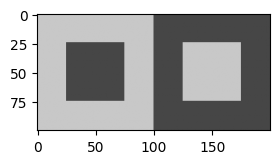

In [69]:
# Novamente, foram inicialmente criados dois quadrados, de cores diferentes.
# Seu tamanho foi configurado para metade dos quadrados originais, e foram
# posicionados via slicing e broadcasting no centro de cada quadrado original.

square3 = np.zeros([50, 50], dtype=np.uint8)
square4 = np.zeros([50, 50], dtype=np.uint8)

square3[:, :] = 200
square4[:, :] = 70

rect[25:75, 125:175] = square3
rect[25:75, 25:75] = square4

plt.figure(figsize = (3,3))
plt.imshow(rect,vmin=0, vmax=255, cmap='gray')

### Exercício 3.2

Baseando-se no tutorial sobre as funções [indices e meshgrid](https://github.com/lrittner/Computacao-Visual/blob/master/tutoriais/02_tutorial_numpy_1_6.ipynb), crie as seguintes imagens sintéticas, plotando o resultado e comentando os métodos utilizados.

**a)** Tabuleiro de xadrez;


Máscara:
 [[ True  True  True ... False False False]
 [ True  True  True ... False False False]
 [ True  True  True ... False False False]
 ...
 [False False False ...  True  True  True]
 [False False False ...  True  True  True]
 [False False False ...  True  True  True]]


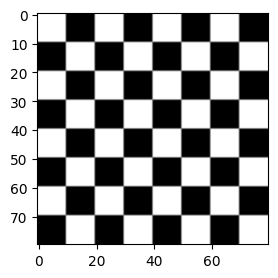

In [70]:
# Primeiramente foi criado um array 80 por 80 através do método np.indices().
# Depois disso, com base nas coordenadas, foi construída uma máscara que
# traduzisse o padrão alternado de um tabuleiro de xadrez. Por fim, após criar
# um array de zeros de 80x80, a máscara foi utilizada para alterar o valor e
# colorir de branco parte dos quadrados no padrão do tabuleiro de xadrez.

r,c = np.indices((80,80))
f = (r//10 + c//10) % 2 == 0
print("Máscara:\n", f)

tabuleiro = np.zeros([80, 80], dtype=np.uint8)

tabuleiro[f] = 255

plt.figure(figsize = (3,3))
plt.imshow(tabuleiro,vmin=0, vmax=255, cmap='gray')

**b)** Função parabólica dada pela soma do quadrado de suas coordenadas;

Array da função:
 [[  0   1   4   9  16  25  36  49  64  81 100 121 144 169 196 225 256 289
  324 361]
 [  1   2   5  10  17  26  37  50  65  82 101 122 145 170 197 226 257 290
  325 362]
 [  4   5   8  13  20  29  40  53  68  85 104 125 148 173 200 229 260 293
  328 365]
 [  9  10  13  18  25  34  45  58  73  90 109 130 153 178 205 234 265 298
  333 370]
 [ 16  17  20  25  32  41  52  65  80  97 116 137 160 185 212 241 272 305
  340 377]
 [ 25  26  29  34  41  50  61  74  89 106 125 146 169 194 221 250 281 314
  349 386]
 [ 36  37  40  45  52  61  72  85 100 117 136 157 180 205 232 261 292 325
  360 397]
 [ 49  50  53  58  65  74  85  98 113 130 149 170 193 218 245 274 305 338
  373 410]
 [ 64  65  68  73  80  89 100 113 128 145 164 185 208 233 260 289 320 353
  388 425]
 [ 81  82  85  90  97 106 117 130 145 162 181 202 225 250 277 306 337 370
  405 442]
 [100 101 104 109 116 125 136 149 164 181 200 221 244 269 296 325 356 389
  424 461]
 [121 122 125 130 137 146 157 170 185 202 221 2

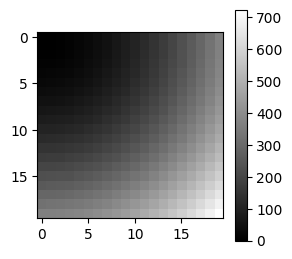

In [71]:
# Utilizando np.indices(), o array com os valores da função é construído
# utilizando diretamente os valores dos índices correspondentes.

r,c = np.indices((20, 20))
f = r**2 + c**2

print("Array da função:\n", f)

grafico = f

plt.figure(figsize = (3,3))
plt.imshow(grafico,vmin=0, vmax=722, cmap='gray')
plt.colorbar()

**c)** Círculo de raio 40, com centro em (0,0);

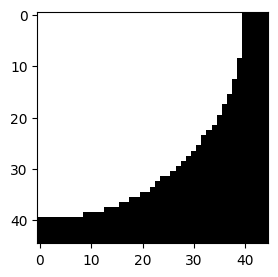

In [72]:
# Utilizando np.indices(), o array com os valores da função é construído
# utilizando diretamente os valores dos índices correspondentes. Depois disso
# seus valores são escalados para 255 (que corresponde à cor branca), enquanto o
# resto da imagem permanece preta (valor 0).

r,c = np.indices((45, 45))
f = ((r**2 + c**2) < 40**2)

grafico = f * 255

plt.figure(figsize = (3,3))
plt.imshow(grafico,vmin=0, vmax=255, cmap='gray')

## Parte 4 - Manipulando imagens com PIL e Numpy 🤖🚫

É possível carregar imagens utilizando **PIL.Image** e convertê-las para um array do Numpy. Para mais informações sobre manipulação e visualização de imagens com PIL, Numpy e Matplotlib, leia o tutorial disponível em ["Lendo e Visualizando Imagens"](https://github.com/lrittner/Computacao-Visual/blob/master/tutoriais/03_Lendo_e_Visualizando_Imagens.ipynb).

Neste caso, vamos abrir uma imagem disponibilizada na web. A função `read_image_url` disponibilizada recebe um url e retorna a imagem:

In [73]:
def read_image_url(url:str) -> ImageFile:
    response = requests.get(url)
    img = Image.open(BytesIO(response.content))

    return img

In [74]:
url = "https://raw.githubusercontent.com/UNICAMP-EA979/EA979-Recursos/b30cf8a41c9b04a7aa20a47e668cee2debd52bc5/imgs/arco-iris-duplo.jpg"
img = read_image_url(url)

### Exercício 4.1

Converta a imagem **img** para um array do numpy, printe o número de dimensões da imagem, seu shape e seu dtype. Comente os métodos utilizados.

In [75]:
# Utilizando os atributos da imagem, como .dtype e .shapem foi facilmente
# possível extrair as informações desejadas. Note que .shape envolve as
# dimensões (altura e largura) da imagem e, também, um conjunto de 3 valores que
# controla a cor (RGB) da imagem.

img_array = np.array(img)
print("Dimensão da imagem: ", img_array.shape[:2])
print("Shape da imagem: ", img_array.shape)
print("dtype da imagem: ", img_array.dtype)


Dimensão da imagem:  (480, 640)
Shape da imagem:  (480, 640, 3)
dtype da imagem:  uint8


### Exercício 4.2

Visualize a imagem anterior com um tamanho 2 x 2 inches. Comente o seu código utilizando a documentação oficial.

<details>
  <summary>Dicas</summary>

  - [matplotlib.pyplot.figure](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.figure.html)
  - [matplotlib.pyplot.imshow](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.imshow.html)
  
</details>

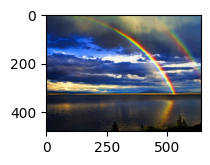

In [76]:
# Aqui foi utilizado o método .figure para configrurar a imagem e .imshow para
# mostrá-la.

plt.figure(figsize = (2,2))
plt.imshow(img_array)

### Exercício 4.3

Selecione e visualize apenas uma região da imagem, usando o slicing do Numpy. Comente os métodos utilizados.

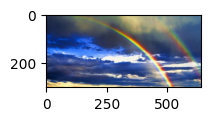

In [77]:
# Com base no método de slicing e na visualização completa da imagem anterior,
# foi possível extrair uma região da imagem que contivesse somente o céu da
# figura escolhida. Os métodos .figure e .imshow são então utilizadas para
# mostrar a imagem.

ceu = img_array[:300, :]
plt.figure(figsize = (2,2))
plt.imshow(ceu)

## Parte 5 - Geração automática de imagens sintéticas e manipulação de arquivos (opcional para EA979) 🤖🚫

### Exercício 5.1

**a)** Quando geramos imagens sintéticas, estamos interessados em criar um conjunto de imagens com algumas características pré-definidas, mas com certa variabilidade. Para exemplificar esse processo, vamos automatizar a criação dos quadrados do exercício 3.1.

Crie uma função que tenha como entradas:
- Inteiro **n** que corresponde ao número de imagens a serem criadas;
- Inteiro **h** que corresponde à "altura" de cada imagem (com "largura" 2\***h**);

e que retorne:
- Um array **I** de shape (n, h, 2\*h, 3), em que cada **I**[n] corresponda a uma imagem similar à imagem gerada no exercício 3.1.b), mas colorida.

A ideia é que a função crie um conjunto de **n** imagens, todas com os "quadrados menores" aproximadamente centralizados nos "quadrados maiores". O tamanho dos "quadrados menores" deve ser igual para todas as imagens do conjunto e definido de forma aleatória. As duas cores utilizadas devem variar para cada imagem e também são definidas aleatoriamente.

Você deve definir certos limites para garantir que a geração das imagens faça sentido: qual a altura mínima das imagens? qual o tamanho mínimo dos quadrados menores? qual a distância mínima entre as bordas dos quadrados menor/maior (para que um não se sobreponha ao outro)?

Teste a função com diferentes valores de entrada, tentando sempre plotar as imagens de cada conjunto gerado em um único plot. Comente sobre as decisões tomadas na criação da função (como os limites que foram definidos) e seu comportamento esperado (como a centralização dos quadrados menores em relação às dimensões da imagem).

In [28]:
# Seu código aqui

**b)** Conjuntos de imagens podem ser armazenados em diferentes formatos e arquivos. Em especial, arquivos *.npz* são capazes de armazenar diversos arrays, organizados de modo semelhante a um dicionário. Como este tipo de arquivo será utilizado novamente em exercícios futuros, vamos treinar sua manipulação.

Utilizando a função do item anterior, crie 4 conjuntos de imagens (**A**, **B**, **C** e **D**) com 10 imagens cada e diferentes valores de **h**. Utilize a função [savez](https://numpy.org/doc/stable/reference/generated/numpy.savez.html) para salvar os 4 arrays em um único arquivo *.npz*, mantendo os nomes dos arrays (**A**, **B**, **C** e **D**). Em seguida, abra o arquivo gerado, imprima os nomes dos arrays armazenados e plote uma imagem de cada conjunto (selecionada aleatoriamente) em um único plot. Comente os métodos utilizados.

In [29]:
# Seu código aqui

## Parte 6 - Extraindo dados de uma imagem (opcional para EA979) 🤖🆗

### Exercício 6.1

Existem diversas funções que calculam dados [matemáticos](https://numpy.org/doc/stable/reference/routines.math.html) e [estatísticos](https://numpy.org/doc/stable/reference/routines.statistics.html) de um array. Esses dados podem ser muito úteis para diversas aplicações em imagens.

**a)** Observe o código abaixo. O que ele está realizando? Qual a importância do valor $-0.397$? Este código funcionaria com outra imagem? Na sua explicação, utilize alguma forma de visualizar o que está acontecendo.

In [30]:
url = "https://raw.githubusercontent.com/UNICAMP-EA979/EA979-Recursos/b30cf8a41c9b04a7aa20a47e668cee2debd52bc5/imgs/keyb.tif"
img = np.array(read_image_url(url))

ops = [np.mean, np.max, np.min, np.std, np.median]
features = []
for op in ops:
    f0 = op(img, axis=0)/255
    f1 = op(img, axis=1)/255
    features.append(np.outer(f1, f0))
test = (features[0]-features[1])/2
mask = test < -0.397

**b)** Você consegue alterar o código para que ele realiza a mesma funcionalidade, mas de forma mais eficiente? Faça uma versão que leia cada elemento da imagem apenas 2 vezes (exemplo: ler uma vez cada linha e cada coluna). Além da eficiência, este método tem alguma outra vantagem? Comente sobre.

In [31]:
# Seu código aqui

# Dicas: Utilizando o Colab

O Google Colaboratory (Colab) permite a execução de Jupyter Notebooks na nuvem, através de navegadores, sem a necessidade de instalação do Jupyter na máquina. Nesta disciplina, os tutoriais e exercícios serão realizados na forma de Jupyter Notebooks através do Colab.

## Conectividade do Colab

O Colab informa que pode ficar conectado por até 12 horas. Porém, esse período varia de acordo com a utilização do Notebook e a iteratividade do código. Em alguns casos, após muito tempo de execução, a conta do Colab pode ficar limitada para utilização. Nestes casos, aconselha-se compartilhar o Notebook através do botão "Compartilhar" no canto superior direito, e executá-lo com outra conta do Google.

## Inserindo novas células

O Colab permite a inserção de células de código ou texto. As células de código podem executar comandos em Python ou shell bash (comandos para terminal Linux). As células de texto permitem a inserção de dados em texto, links, tópicos e imagens.

Para inserir uma nova célula, posicione o mouse entre duas células e clique no tipo da célula desejada (Código ou Texto):

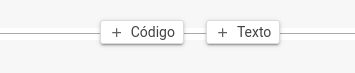

Também é possível inserir novas células de código com os comandos "Ctrl+M B".

As células podem ter sua ordem de execução alterada se forem pressionadas e "arrastadas". Além disso, a mudança de ordem pode ser efetuada pelas setas na figura a seguir, ou com os comandos "Ctrl+M K" (mover para cima) ou "Ctrl+M J" (Mover para baixo).

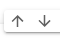

## Executando células de código

As células de código podem ser executadas clicando no ícone "Play", ao lado esquerdo da célula, ou através dos comandos "Shift+Enter" ou "Ctrl+Enter". Após a execução da célula, o índice de execução ficará entre os colchetes [ ].

Também é possível:
1.   Executar todas as células: Ambiente de Execução > Executar tudo (ou utilizando Ctrl+F9);
2.   Executar todas as células após a célula em que está o cursor: Ambiente de Execução > Executar após (ou utilizando Ctrl+F10);
3.   Executar todas as células antes da célula em que está o cursor: Ambiente de Execução > Executar antes (ou utilizando Ctrl+F8);

No caso da execução correta, um ícone de ok estará ao lado esquerdo.

No caso de erros, um ponto de exclamação aparecerá no lado esquerdo e o erro será detalhado abaixo da célula. A execução é interrompida com o erro.

In [32]:
print("Exemplo de execução")

Exemplo de execução


In [33]:
print(f"Exemplo de erro de execução (variável não declarada): {m}")

NameError: name 'm' is not defined

Para execução de comandos shell bash, utiliza-se o sinal "!" antes do código.

Abaixo, seguem exemplos para:

1.   Listar os arquivos do diretório atual
2.   Printar o caminho do diretório atual
3. Printar as configurações da GPU utilizada (é necessário estar com GPU habilitada: Ambiente de Execução > Alterar o tipo do ambiente de execução > Acelerador de Hardware).

In [ ]:
!ls

In [ ]:
!pwd

In [ ]:
!nvidia-smi


## Utilizando Colab com o Google Drive

O Colab permite o vínculo de uma conta no Google Drive para carregar ou salvar arquivos. É necessário importar o pacote drive do colab e montá-lo, como segue. Na primeira execução após a conexão do notebook, será necessário realizar a autenticação na conta e permitir a conexão do colab com o drive.

Por padrão, os notebooks gerados pelo colab são salvos na pasta 'Colab Notebooks', no Drive. Porém, é possível alterar o local onde o notebook será salvo.

É possível verificar os arquivos na pasta de trabalho utilizando o comando shell bash "ls". Também é possível alterar a pasta de trabalho atual com o comando "cd". Exercite a execução destes comandos utilizando seu Google Drive.

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

## Utilizando arquivos compartilhados

O Colab permite apenas que sejam utilizados arquivos do Drive da própria conta, ou de drives compartilhados. Para se utilizar arquivos ou pastas compartilhados, pode-se adicionar um atalho à própria conta do Drive.

Adicione um atalho ao seu Google Drive da pasta compartilhada (indicada na descrição do exercício no classroom). Liste os arquivos que estão contidos na pasta "Dados/Ex01" utilizando a função **os.listdir**.

In [ ]:
import os
#IMPORTANTE: substitua "NOME_DA_PASTA_COMPARTILHADA" abaixo pelo nome correspondente
list_files = os.listdir("gdrive/MyDrive/NOME_DA_PASTA_COMPARTILHADA/Dados/Ex01")
for file in list_files:
  print(file)

### Salvando arquivos no Drive

Um arquivo, como uma imagem PIL.Image, pode ser salvo com o método save. No entanto, o path deve existir.

OBS: um path pode ser criado via shell bash com **!mkdir -p path**.
O -p promove a criação de subdiretórios que ainda não existem.

In [ ]:
from PIL import Image
import numpy as np
!mkdir -p gdrive/MyDrive/'Colab Notebooks'/'Processamento de Imagens'/Ex01
#IMPORTANTE: substitua "NOME_DA_PASTA_COMPARTILHADA" abaixo pelo nome correspondente
path_img = "gdrive/MyDrive/NOME_DA_PASTA_COMPARTILHADA/Dados/Ex01/arco-iris-duplo.jpg"
path_save = "gdrive/MyDrive/Colab Notebooks/Processamento de Imagens/Ex01/Ex1_arco_iris.png"
pil_img = Image.fromarray(np.array(Image.open(path_img)))
pil_img.save(path_save)

## Snipets de código

O Colab fornece vários códigos prontos em Ajuda > Pesquisar snipets de código. Os snipets também são acessíveis através dos comandos Ctrl+Alt+P.
